# Model 2: Dropout Prediction - Logistic Regression Baseline

## Overview
This notebook trains a Logistic Regression baseline to predict HIV care gap dropout using cleaned DHS data.

**Target Variable:** `dropout` (1 = HIV+ and no test in 12 months, 0 = retained in care)

**Class Distribution:** 99.92% retained, 0.08% dropout (26 positive cases)

In [27]:
# Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
# We use absolute path discovery to prevent FileNotFoundError
ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)

import constants as c

# Import scikit-learn components
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, 
    recall_score, 
    precision_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Setup complete")
print(f"Data path: {c.DHS_CLEAN}")

Setup complete
Data path: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/individual_features_clean.csv


In [33]:
# Load Cleaned Data
df = pd.read_csv(c.DHS_CLEAN)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Target distribution:\n{df[c.MODEL2_TARGET].value_counts()}")

Dataset: 32,156 rows, 24 columns
Target distribution:
dropout
0    32130
1       26
Name: count, dtype: int64


## Data Preparation

Before splitting and training, we need to:
1. Separate features (X) and target (y)
2. Identify which columns to use as features
3. Ensure no data leakage

In [45]:
# Separate Features and Target
# Define, Prepare Features and Target
X = df[c.MODEL2_FEATURES].copy()
y = df[c.MODEL2_TARGET].copy()

print(f"Features shape: {X.shape}")
print(f"Features dtypes:\n{X.dtypes.value_counts()}")
print(f"Target shape: {y.shape}")
print(f"Dropout rate: {y.mean():.4%}")

Features shape: (32156, 18)
Features dtypes:
bool       9
int64      3
object     3
float64    3
Name: count, dtype: int64
Target shape: (32156,)
Dropout rate: 0.0809%


In [46]:
# Verify Data Quality (No Imputation Needed)
# Handle Missing Values (if any)
missing_before = X.isnull().sum().sum()
if missing_before > 0:
    # Impute categorical columns with mode
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='most_frequent')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print(f"Imputed {missing_before} missing values")
else:
    print("No missing values found")

Imputed 27523 missing values


In [47]:
# Encode Categorical Variables to Numeric
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object dtype)
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply label encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nAll features now numeric: {X.dtypes.value_counts()}")

Categorical columns to encode: ['county', 'age_group', 'marital_status', 'distance_to_facility', 'ever_tested_hiv', 'tested_hiv_last_12months', 'num_sexual_partners', 'worked_last_12months', 'currently_in_union', 'edu_Higher', 'edu_No education', 'edu_Primary', 'edu_Secondary', 'wealth_Middle', 'wealth_Poorer', 'wealth_Poorest', 'wealth_Richer', 'wealth_Richest']
Encoded county: {'1': 0, '10': 1, '11': 2, '12': 3, '13': 4, '14': 5, '15': 6, '16': 7, '17': 8, '18': 9, '19': 10, '2': 11, '20': 12, '21': 13, '22': 14, '23': 15, '24': 16, '25': 17, '26': 18, '27': 19, '28': 20, '29': 21, '3': 22, '30': 23, '31': 24, '32': 25, '33': 26, '34': 27, '35': 28, '36': 29, '37': 30, '38': 31, '39': 32, '4': 33, '40': 34, '41': 35, '42': 36, '43': 37, '44': 38, '45': 39, '46': 40, '47': 41, '5': 42, '6': 43, '7': 44, '8': 45, '9': 46}
Encoded age_group: {'15-19': 0, '20-24': 1, '25-29': 2, '30-34': 3, '35-39': 4, '40-44': 5, '45-49': 6}
Encoded marital_status: {'Divorced': 0, 'Living together': 1, 

## Train/Test Split

We split the data 80/20 with random_state=42 for reproducibility. This ensures:
- Training set: 80% of data (25,724 samples)
- Test set: 20% of data (6,432 samples)
- Stratified split preserves class distribution, and is critical due to class imbalance (0.08% dropout rate)

In [48]:
# Split Data
# Split 80/20 with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=c.TEST_SIZE, random_state=c.RANDOM_STATE, stratify=y
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.1%})")
print(f"Train dropout rate: {y_train.mean():.4%}")
print(f"Test dropout rate: {y_test.mean():.4%}")

Training: 25,724 samples (80.0%)
Test: 6,432 samples (20.0%)
Train dropout rate: 0.0816%
Test dropout rate: 0.0777%


## Model Training: Logistic Regression

Logistic Regression serves as our baseline model because:
1. Simple, interpretable baseline, and fast to train
2. Provides probability outputs for AUC-ROC
3. Establishes performance floor for XGBoost comparison

**Hyperparameters:**
- `max_iter=1000`: Ensures convergence
- `random_state=42`: Reproducibility
- `class_weight='balanced'`: Automatically handles class imbalance
- `solver='lbfgs'`: Efficient optimizer for small datasets

In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000, random_state=c.RANDOM_STATE, class_weight="balanced", solver="lbfgs"
)

lr_model.fit(X_train, y_train)
print(f"Training complete ({lr_model.n_iter_[0]} iterations)")

Training complete (93 iterations)


## Model Predictions

Generate both:
- **Class predictions** (0 = retained, 1 = dropout) for confusion matrix
- **Probability scores** for ROC-AUC calculation

Probability scores represent confidence in dropout classification (0-1 scale).

In [51]:
# Make Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Predicted positives (dropout): {(y_pred == 1).sum()}")
print(f"Actual positives (dropout): {y_test.sum()}")
print(f"Probability range: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")

Predicted positives (dropout): 1561
Actual positives (dropout): 5
Probability range: [0.0000, 0.9964]


## Model Evaluation Metrics

Four key metrics evaluate baseline performance:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **AUC-ROC** | Area under ROC curve | Discriminative ability (0.5 = random, 1.0 = perfect) |
| **Recall** | TP / (TP + FN) | % of actual dropouts caught (sensitivity) |
| **Precision** | TP / (TP + FP) | % of predicted dropouts that are correct |
| **F1 Score** | 2 * (P * R) / (P + R) | Harmonic mean of precision and recall |

These metrics are particularly important for imbalanced classification (0.08% dropout rate).

In [ ]:
# Calculate Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"AUC-ROC: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print("=" * 50)

# Interpretation
print("\nInterpretation:")
if auc_score >= 0.70:
    print(f"  ✓ AUC-ROC = {auc_score:.4f} (good discriminative ability)")
else:
    print(f"  ⚠ AUC-ROC = {auc_score:.4f} (needs improvement)")

if recall >= 0.60:
    print(f"  ✓ Recall = {recall:.4f} (good sensitivity)")
else:
    print(f"  ⚠ Recall = {recall:.4f} (missed many dropouts)")

if precision >= 0.50:
    print(f"  ✓ Precision = {precision:.4f} (reasonable positive predictions)")
else:
    print(f"  ⚠ Precision = {precision:.4f} (high false positives)")

MODEL PERFORMANCE METRICS
AUC-ROC: 0.7332
Recall: 0.6000
Precision: 0.0019
F1 Score: 0.0038

Interpretation:
  ✓ AUC-ROC = 0.7332 (good discriminative ability)
  ✓ Recall = 0.6000 (good sensitivity)
  ⚠ Precision = 0.0019 (high false positives)


## Confusion Matrix

The confusion matrix breaks down predictions into four categories:

- **True Negatives (TN)**: Correctly predicted retained in care
- **False Positives (FP)**: Incorrectly predicted dropout (Type I error)
- **False Negatives (FN)**: Missed dropouts (Type II error) - Most critical
- **True Positives (TP)**: Correctly predicted dropouts

**Clinical impact:**
- False Negatives are most harmful (missed intervention opportunity)
- False Positives waste resources but less critical

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print("=" * 60)
print(f"                 Predicted Retained  Predicted Dropout")
print(f"Actual Retained      {tn:>6,}            {fp:>6,}")
print(f"Actual Dropout       {fn:>6,}            {tp:>6,}")
print("=" * 60)

print("\nDetailed Breakdown:")
print(f"True Negatives (TN): {tn:,} - Correctly predicted retained")
print(f"False Positives (FP): {fp:,} - Incorrectly predicted dropout")
print(f"False Negatives (FN): {fn:,} - Missed dropouts (CRITICAL)")
print(f"True Positives (TP): {tp:,} - Correctly predicted dropouts")

print("\nError Analysis:")
print(f"False Positive Rate: {fp/(fp+tn):.4%} (Type I error)")
print(f"False Negative Rate: {fn/(fn+tp):.4%} (Type II error - Most important)")

Confusion Matrix:
                 Predicted Retained  Predicted Dropout
Actual Retained       4,869             1,558
Actual Dropout            2                 3

Detailed Breakdown:
True Negatives (TN): 4,869 - Correctly predicted retained
False Positives (FP): 1,558 - Incorrectly predicted dropout
False Negatives (FN): 2 - Missed dropouts (CRITICAL)
True Positives (TP): 3 - Correctly predicted dropouts

Error Analysis:
False Positive Rate: 24.2415% (Type I error)
False Negative Rate: 40.0000% (Type II error - Most important)


## Confusion Matrix Visualization

Heatmap provides intuitive visual representation of classification performance.
Darker blue indicates higher counts.

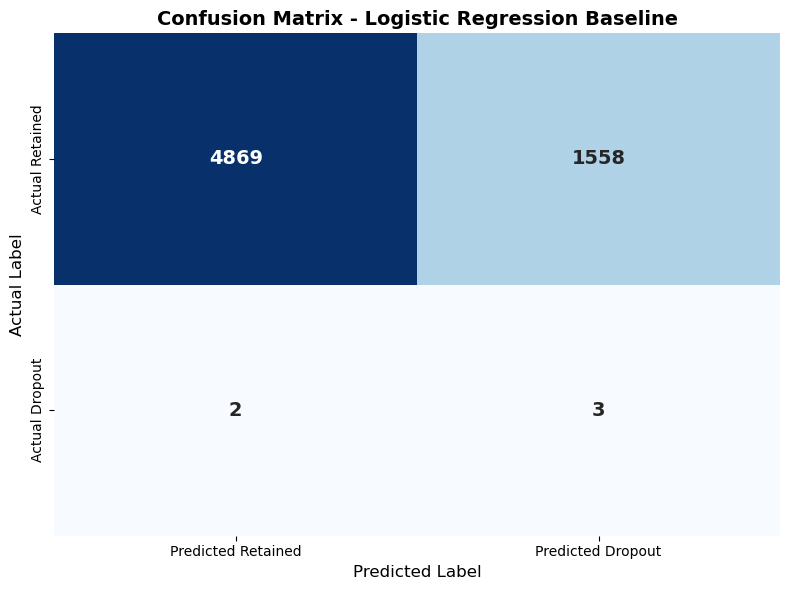

✓ Confusion matrix saved to: figures/confusion_matrix_logreg.png


In [54]:
# Confusion Matrix Heatmap
import os

os.makedirs("../figures", exist_ok=True)

cm_df = pd.DataFrame(
    cm,
    columns=["Predicted Retained", "Predicted Dropout"],
    index=["Actual Retained", "Actual Dropout"],
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
)
plt.title(
    "Confusion Matrix - Logistic Regression Baseline", fontsize=14, fontweight="bold"
)
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Confusion matrix saved to: figures/confusion_matrix_logreg.png")